# SMS Spam EDA

In [1]:
from pyspark.sql import SparkSession, functions as F
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

spark = SparkSession.builder.appName("sms-spam-eda").master("local[*]").getOrCreate()
spark.sparkContext.setLogLevel("WARN")

print("Spark version:", spark.version)

Spark version: 4.0.2


In [3]:
dataset_root = Path(kagglehub.dataset_download('uciml/sms-spam-collection-dataset'))
print('Path to dataset files:', dataset_root)

data_path = dataset_root / 'spam.csv'
print('Using:', data_path)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset
Using: /kaggle/input/sms-spam-collection-dataset/spam.csv


In [4]:
df = spark.read.csv(str(data_path), header=True, inferSchema=True, multiLine=True)

print('Columns:', df.columns)
df.show(5, truncate=False)

Columns: ['v1', 'v2', '_c2', '_c3', '_c4']
+----+-----------------------------------------------------------------------------------------------------------------------------------------------------------+----+----+----+
|v1  |v2                                                                                                                                                         |_c2 |_c3 |_c4 |
+----+-----------------------------------------------------------------------------------------------------------------------------------------------------------+----+----+----+
|ham |Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                                            |NULL|NULL|NULL|
|ham |Ok lar... Joking wif u oni...                                                                                                                              |NULL|NULL|NULL|
|spam|Free entry in 2 a wkly comp to win FA Cup final tkts 21st May

In [5]:
print('Columns:', df.columns)
print('Row count:', df.count())
df.select(df.columns[:2]).show(5, truncate=False)

Columns: ['v1', 'v2', '_c2', '_c3', '_c4']
Row count: 5572
+----+-----------------------------------------------------------------------------------------------------------------------------------------------------------+
|v1  |v2                                                                                                                                                         |
+----+-----------------------------------------------------------------------------------------------------------------------------------------------------------+
|ham |Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                                            |
|ham |Ok lar... Joking wif u oni...                                                                                                                              |
|spam|Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt r

In [6]:
clean_df = (
    df.select(
        F.col('v1').alias('label_text'),
        F.col('v2').alias('message')
    )
    .withColumn('label_text', F.lower(F.trim(F.col('label_text'))))
    .withColumn('message', F.trim(F.col('message')))
    .filter(F.col('message').isNotNull() & (F.length('message') > 0))
    .withColumn('label', F.when(F.col('label_text') == 'spam', 1).otherwise(0))
    .withColumn('msg_len_chars', F.length('message'))
    .withColumn('msg_len_words', F.size(F.split(F.col('message'), r'\s+')))
    .select('label', 'label_text', 'message', 'msg_len_chars', 'msg_len_words')
)

clean_df.cache()
print('Clean rows:', clean_df.count())
clean_df.show(5, truncate=False)

Clean rows: 5572
+-----+----------+-----------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+-------------+
|label|label_text|message                                                                                                                                                    |msg_len_chars|msg_len_words|
+-----+----------+-----------------------------------------------------------------------------------------------------------------------------------------------------------+-------------+-------------+
|0    |ham       |Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                                            |111          |20           |
|0    |ham       |Ok lar... Joking wif u oni...                                                                                                                            

In [7]:
class_counts = clean_df.groupBy('label_text').count().orderBy('count', ascending=False)
class_counts.show()

spam_count = clean_df.filter(F.col('label') == 1).count()
ham_count = clean_df.filter(F.col('label') == 0).count()
print(f'Ham:Spam = {ham_count}:{spam_count} ({ham_count/spam_count:.2f}:1)')

clean_df.select(
    F.mean('msg_len_chars').alias('avg_chars'),
    F.mean('msg_len_words').alias('avg_words')
).show()

clean_df.selectExpr(
    'percentile_approx(msg_len_chars, array(0.25, 0.5, 0.75, 0.95)) as chars_percentiles',
    'percentile_approx(msg_len_words, array(0.25, 0.5, 0.75, 0.95)) as words_percentiles'
).show(truncate=False)

+----------+-----+
|label_text|count|
+----------+-----+
|       ham| 4825|
|      spam|  747|
+----------+-----+

Ham:Spam = 4825:747 (6.46:1)
+-----------------+------------------+
|        avg_chars|         avg_words|
+-----------------+------------------+
|80.07573582196697|15.494436468054559|
+-----------------+------------------+

+------------------+-----------------+
|chars_percentiles |words_percentiles|
+------------------+-----------------+
|[35, 61, 121, 161]|[7, 12, 23, 33]  |
+------------------+-----------------+



In [8]:
clean_df = (
    clean_df
    .withColumn('label_text', F.regexp_replace(F.col('label_text'), '"', ''))
    .filter(F.col('label_text').isin('ham', 'spam'))
    .withColumn('label', F.when(F.col('label_text') == 'spam', 1).otherwise(0))
)

clean_df.groupBy('label_text').count().orderBy('count', ascending=False).show()
print('Rows after label cleanup:', clean_df.count())

+----------+-----+
|label_text|count|
+----------+-----+
|       ham| 4825|
|      spam|  747|
+----------+-----+

Rows after label cleanup: 5572


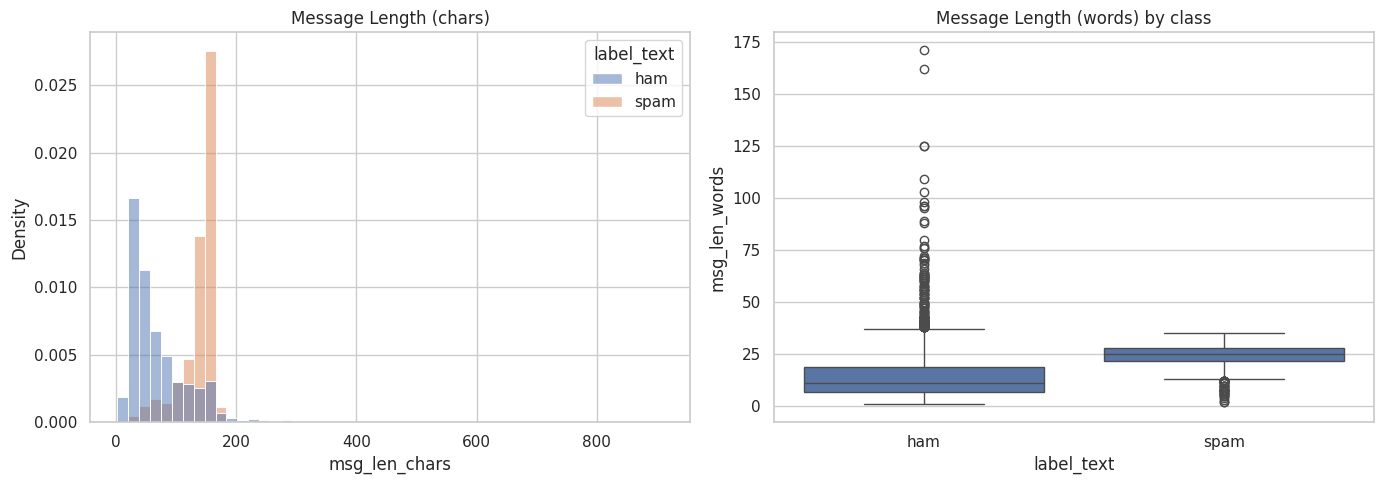

In [9]:
pdf = clean_df.select('label_text', 'msg_len_chars', 'msg_len_words').toPandas()

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=pdf,
    x='msg_len_chars',
    hue='label_text',
    bins=50,
    stat='density',
    common_norm=False,
    ax=axes[0]
)
axes[0].set_title('Message Length (chars)')

sns.boxplot(data=pdf, x='label_text', y='msg_len_words', ax=axes[1])
axes[1].set_title('Message Length (words) by class')

plt.tight_layout()
plt.show()

In [10]:
artifact_root = Path('/content/artifacts')
artifact_root.mkdir(parents=True, exist_ok=True)

class_counts = clean_df.groupBy('label_text').count().orderBy('label_text')
class_counts.toPandas().to_csv(artifact_root / 'class_counts.csv', index=False)
pdf.to_csv(artifact_root / 'eda_message_lengths.csv', index=False)

clean_df.write.mode('overwrite').parquet(str(artifact_root / 'clean_sms.parquet'))

print('Saved to:', artifact_root)
print('Files: class_counts.csv, eda_message_lengths.csv, clean_sms.parquet')

Saved to: /content/artifacts
Files: class_counts.csv, eda_message_lengths.csv, clean_sms.parquet
